In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from autolog import ASLT

In [42]:
'''
The data used here is clean TESS TOI table from NASA Exoplanet Archive

The raw data can be accessed in this link:
https://exoplanetarchive.ipac.caltech.edu/docs/data.html
'''

df = pd.read_csv('data.csv')
df

,st_pmra,st_pmdec,pl_tranmid,pl_orbper,pl_trandurh,pl_trandep,pl_rade,pl_insol,pl_eqt,st_tmag,st_dist,st_teff,st_logg,st_rad,sin_ra,sin_dec,disp
0,-26.931999,-2.901,2459985.25,4.550594,2.654000,3731.000000,7.108410,414.774994,1257.000000,9.1309,100.710999,5613.000000,4.141735,1.090000,0.859809,-0.192548,F
1,-29.100000,-6.800,2459230.00,2.504792,4.379756,2270.540283,8.695089,1750.932617,1649.822021,9.2386,467.458600,6616.000000,4.013730,1.534290,0.825515,-0.458239,F
2,12.641000,-16.011,2458326.00,1.430370,1.616599,18960.712891,13.187450,1281.240845,1525.904785,12.4069,375.309998,5600.000000,4.488510,0.890774,-0.659516,-0.827785,C
3,-3.973000,7.061,2459232.25,5.425555,3.963748,14939.633789,17.519110,273.588074,1037.275269,7.6095,510.295013,8868.700195,4.324911,1.322581,0.954833,-0.528935,F
4,-13.063000,9.737,2459985.75,1.409518,0.948500,2841.510254,13.564258,1650.422119,1625.618042,7.6780,224.671997,9307.000000,4.035000,2.351183,0.972118,-0.562413,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1599,-1.513000,9.463,2460686.00,5.214676,4.983063,3754.150635,14.447677,1037.069946,1607.354126,10.1887,375.582001,6080.000000,3.780000,2.270000,0.981874,-0.507418,F
1600,-2.927000,-2.298,2458494.00,4.765160,2.892000,647.689026,8.447212,2214.790039,1911.000000,10.0813,822.322021,9412.500000,4.036750,2.237777,0.923098,-0.439636,F
1601,2.061000,-7.082,2458493.50,3.443800,2.572000,7260.750000,16.310537,1413.670044,1708.000000,10.0781,1080.880005,4805.200195,4.205453,1.570283,0.934755,0.096938,F
1602,-3.900000,3.866,2458494.75,14.537800,6.826000,4040.000000,16.052299,1884.820724,1745.013098,9.7925,379.692993,8007.000000,4.217000,2.050000,0.871642,-0.334070,F


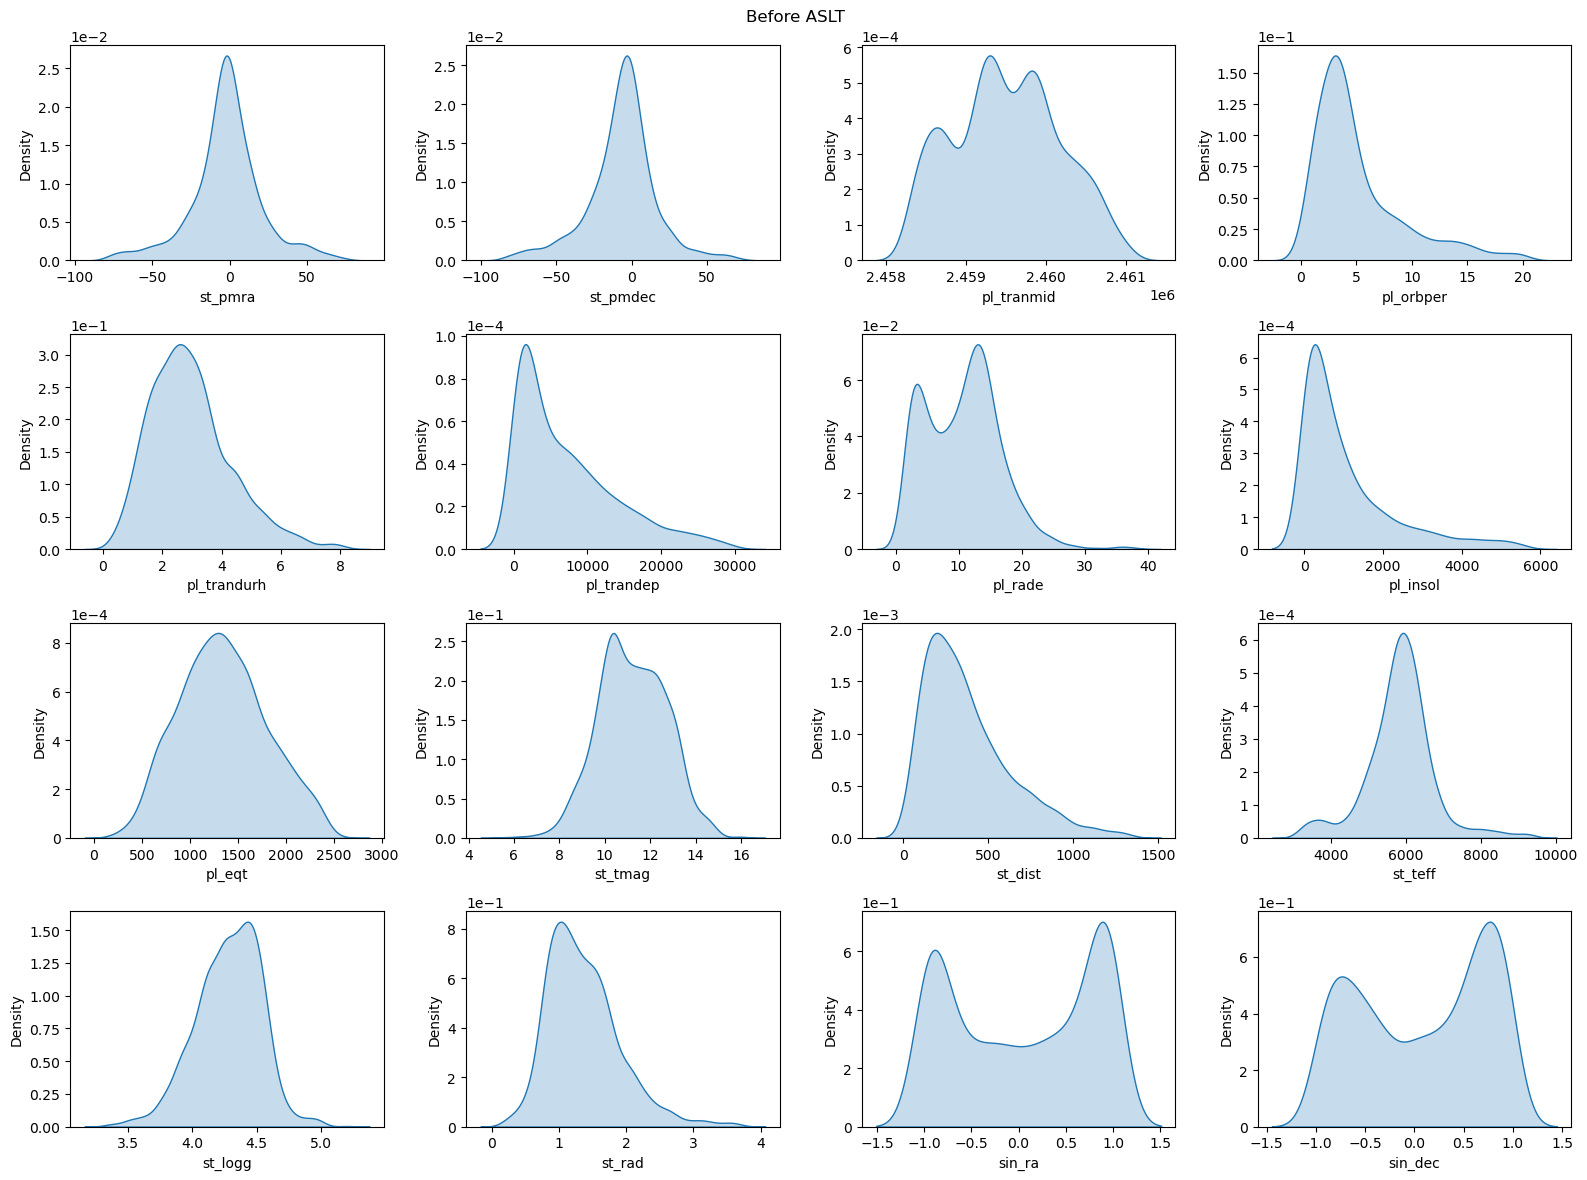

In [29]:
X = df.drop('disp',axis=1)
y = df['disp']

X_cols = X.columns
plt.figure(figsize=(16,12))
for i,col in enumerate(X_cols):
    plt.subplot(4,4,i+1)
    sns.kdeplot(X,x=col,fill=True)
    ax = plt.gca()
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.suptitle('Before ASLT')
plt.tight_layout()
plt.show()

# Method 1: Direct Application

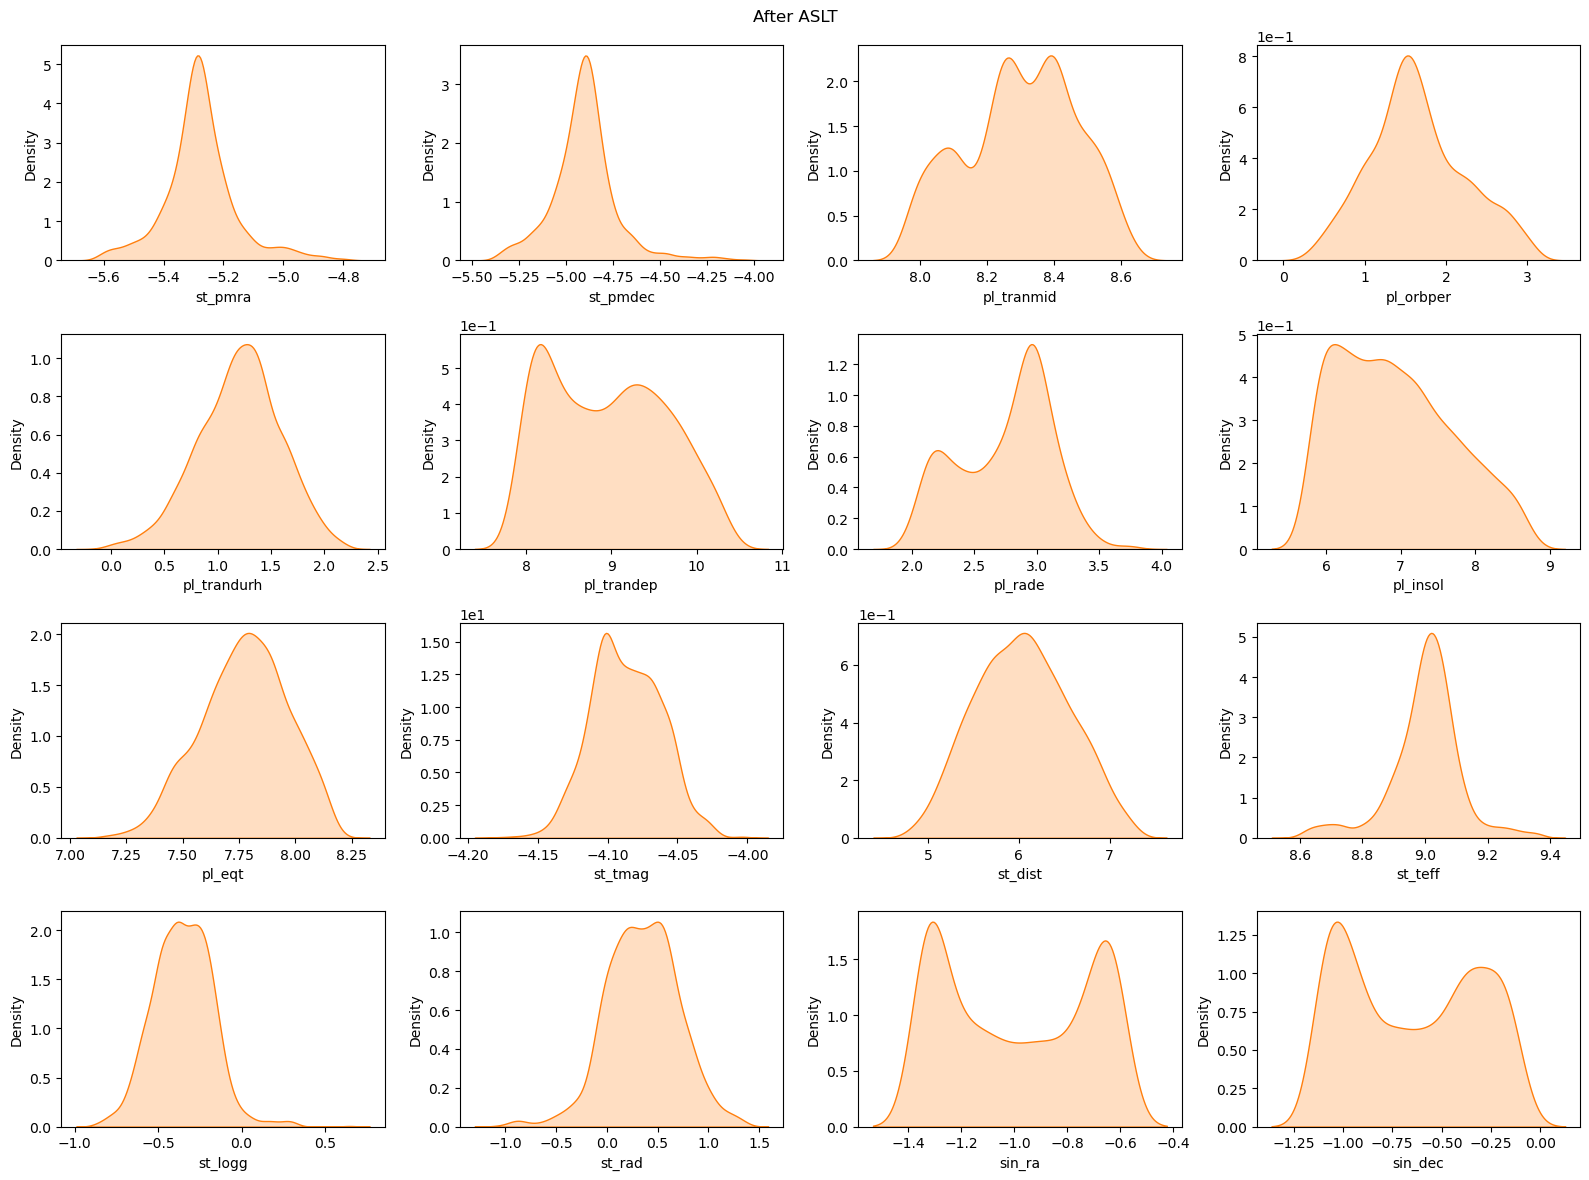

In [40]:
# Transform X using ASLT
aslt = ASLT(beta=10)
X_aslt = aslt.fit_transform(X)

# Turn X_aslt to pd.DataFrame for plotting purpose
X_aslt = pd.DataFrame(X_aslt,columns=X_cols)

# Plotting
plt.figure(figsize=(16,12))
for i,col in enumerate(X_cols):
    plt.subplot(4,4,i+1)
    sns.kdeplot(X_aslt,x=col,fill=True,color='C1')
    ax = plt.gca()
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.suptitle('After ASLT')
plt.tight_layout()
plt.show()

# Method 2: Through Scikit-Learn Estimator

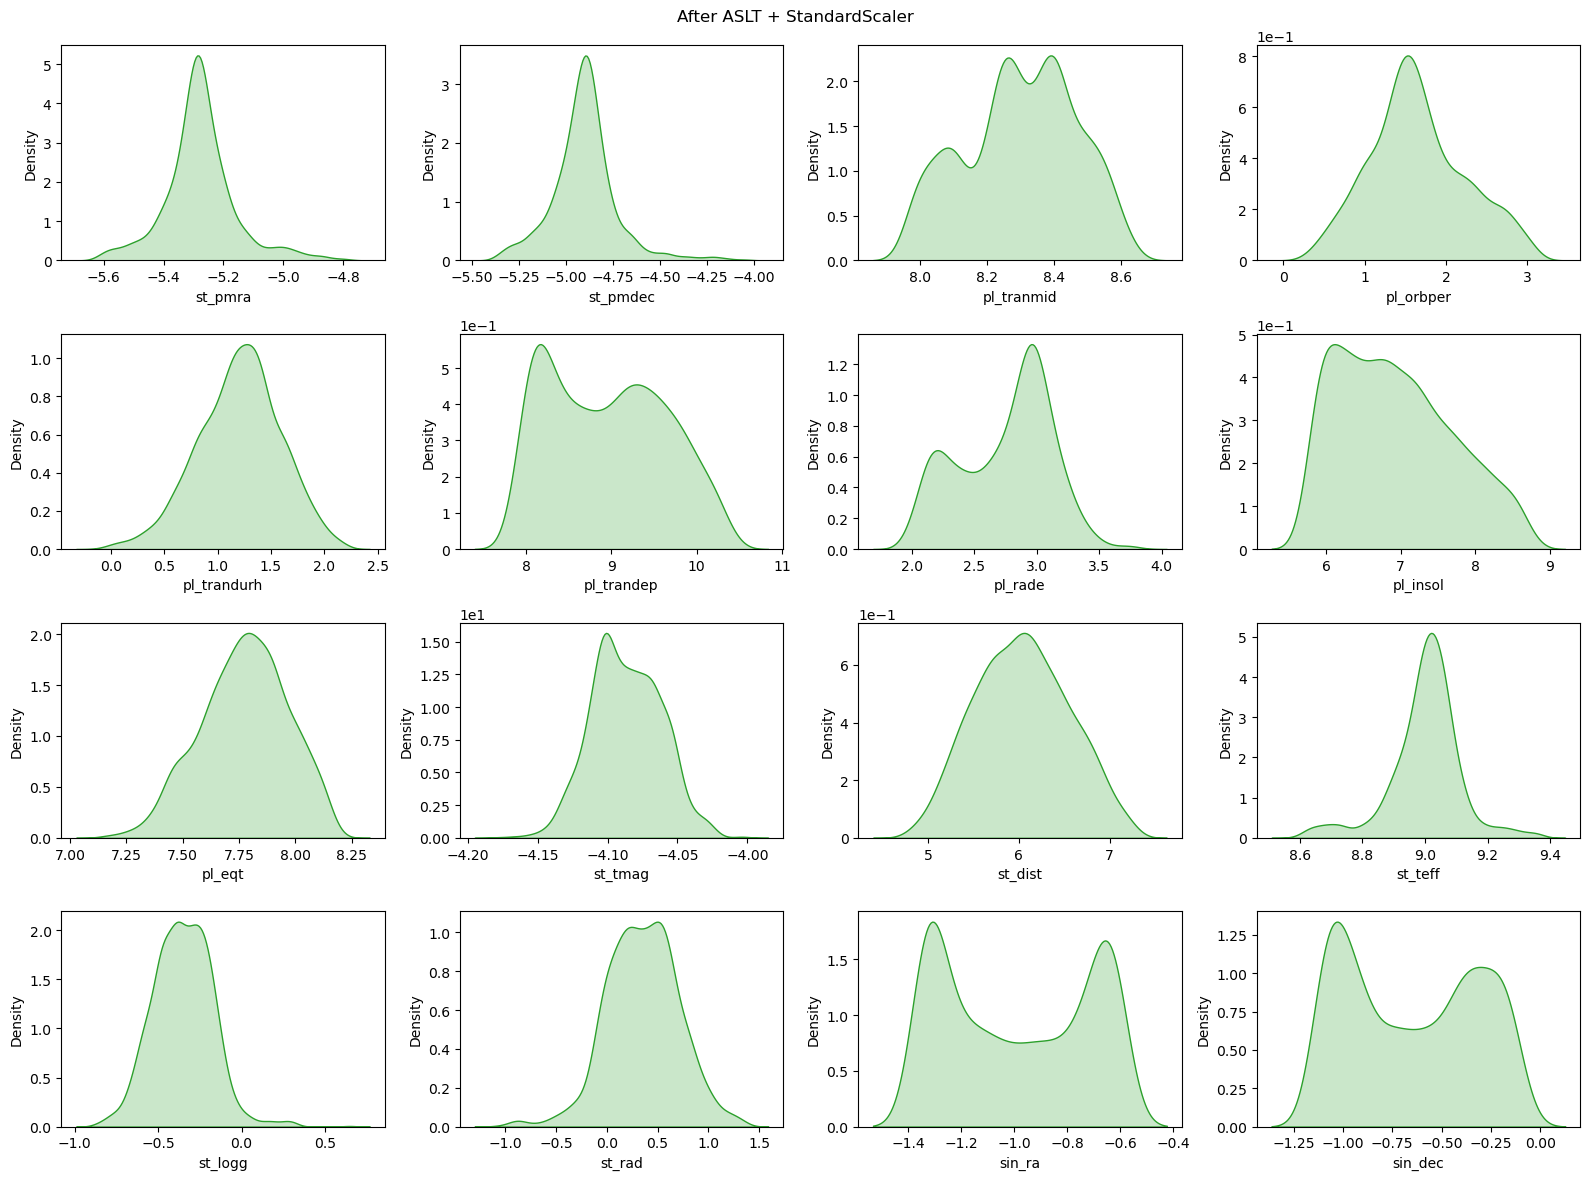

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Use Scikit-Learn Pipeline to preprocess the data
pl = Pipeline([
    ('aslt',ASLT(beta=10)),
    ('scaler',StandardScaler())
])
X_aslt_pl = pl.fit_transform(X)

# Turn X_aslt to pd.DataFrame for plotting purpose
X_aslt_pl = pd.DataFrame(X_aslt,columns=X_cols)

# Plotting
plt.figure(figsize=(16,12))
for i,col in enumerate(X_cols):
    plt.subplot(4,4,i+1)
    sns.kdeplot(X_aslt_pl,x=col,fill=True,color='C2')
    ax = plt.gca()
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.suptitle('After ASLT + StandardScaler')
plt.tight_layout()
plt.show()

# Comparison on Some Columns

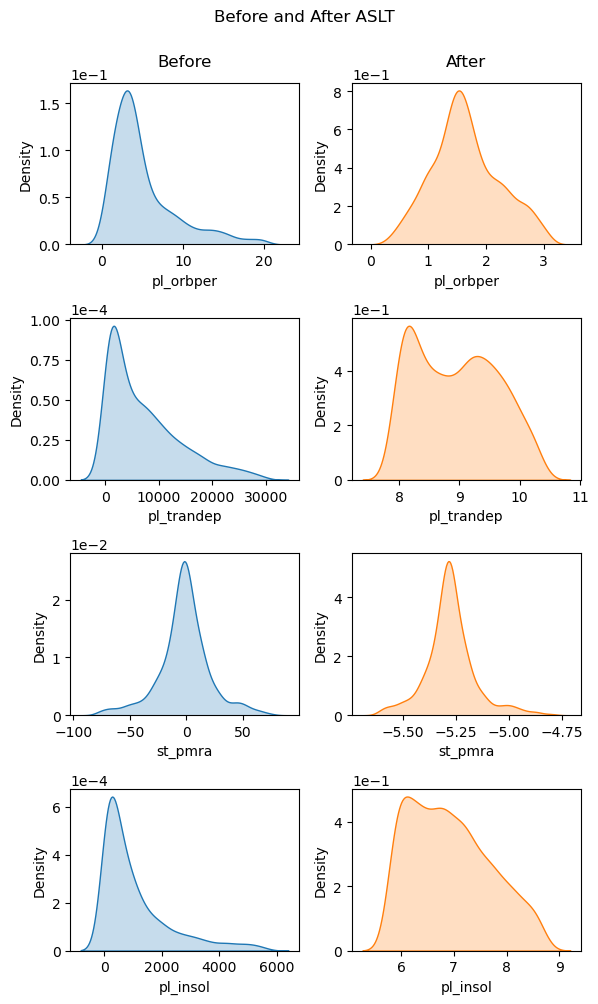

In [63]:
vis_cols = ['pl_orbper','pl_trandep','st_pmra','pl_insol']

plt.figure(figsize=(6,10))
for i,col in enumerate(vis_cols):
    plt.subplot(4,2,(i*2)+1)
    sns.kdeplot(X,x=col,fill=True,color='C0')
    ax = plt.gca()
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    if i == 0:
        plt.title('Before',y=1.05)

    plt.subplot(4,2,(i*2)+2)
    sns.kdeplot(X_aslt,x=col,fill=True,color='C1')
    ax = plt.gca()
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    if i == 0:
        plt.title('After',y=1.05)
plt.suptitle('Before and After ASLT',y=1.00)
plt.tight_layout()
plt.show()